In [1]:
import pandas as pd
import scanpy as sc

In [2]:
breast_cancer_palbociclib = sc.read_h5ad('../data/scDrugAtlas/ea472fa4aec64cabaef5194af0ba5ba0.h5ad')
breast_cancer_palbociclib

AnnData object with n_obs × n_vars = 1761 × 18919
    obs: 'drug', 'response', 'batch'
    var: 'gene'
    uns: 'neighbors', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

/var/folders/6k/gr_1_h_97154rq71pm_q3jn40000gn/T/ipykernel_12664/957577652.py:4: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  print("obsm:", adata.obsm_keys())


obsm: ['X_pca']
uns: ['neighbors', 'pca', 'rank_genes_groups']


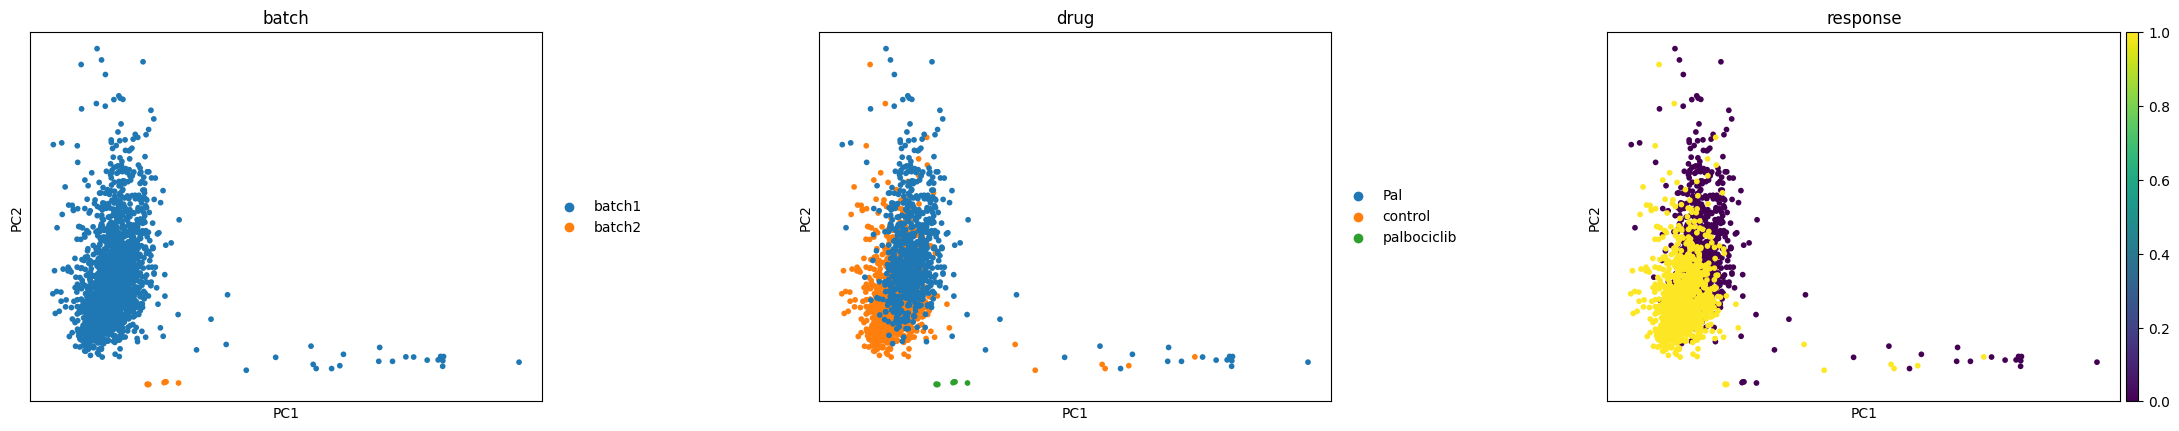

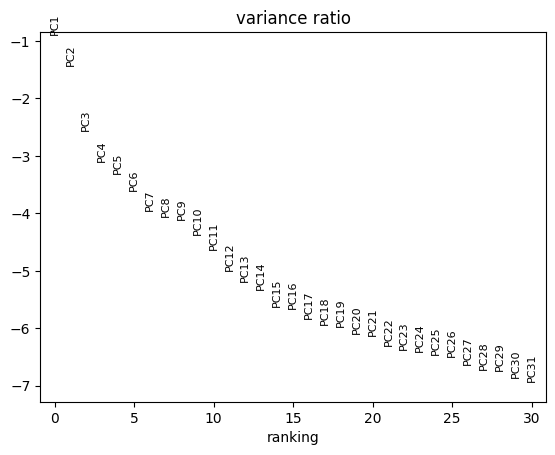

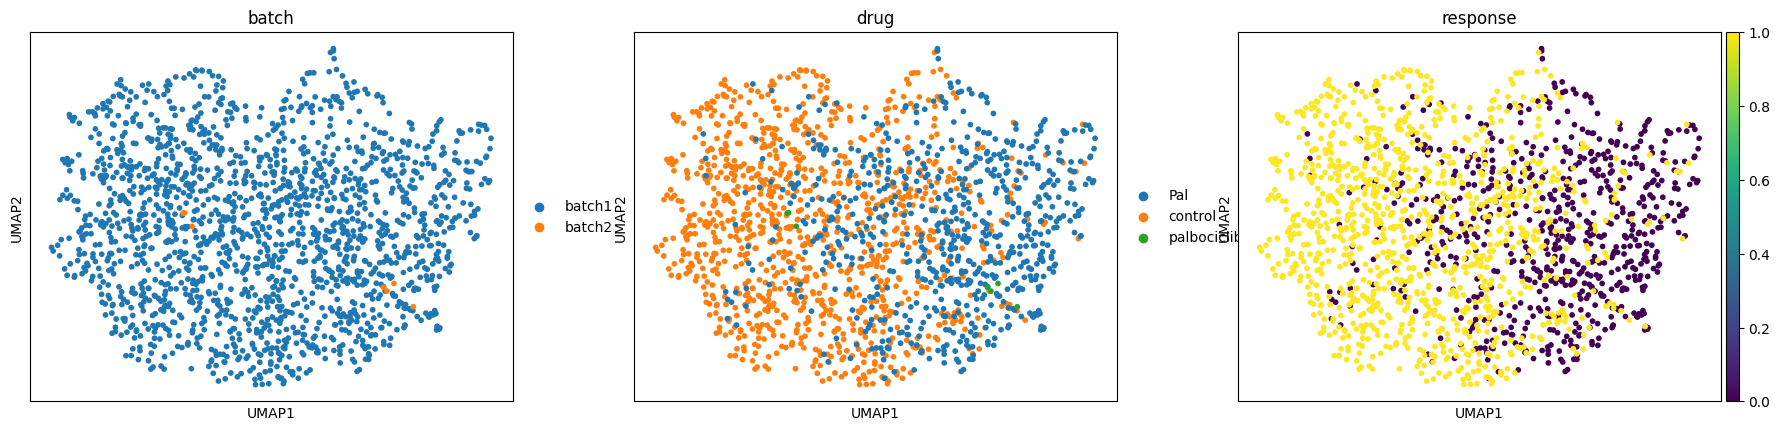

In [8]:
adata = breast_cancer_palbociclib

# See what embeddings/results already exist
print("obsm:", adata.obsm_keys())
print("uns:", list(adata.uns.keys())[:20])

# --- PCA plots (usually available since you have X_pca already) ---
sc.pl.pca(adata, color=["batch", "drug", "response"], wspace=0.4)
sc.pl.pca_variance_ratio(adata, log=True)

# --- UMAP: compute if missing ---
if "X_umap" not in adata.obsm:
    # This will work if neighbors already exist in adata.uns["neighbors"]
    sc.tl.umap(adata)

sc.pl.umap(adata, color=["batch", "drug", "response"])